# Multitask RNN — Driscoll 2024 (15 Tasks)
Make sure to run with GPU in Colab.

In [17]:
# ── Cell 1: Imports & Device ─────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
else:
    print('WARNING: No GPU found. Training will be very slow. In Colab: Runtime -> Change runtime type -> T4 GPU')

Using device: cuda
Tesla T4


In [18]:
# ── Cell 2: Task Registry ────────────────────────────────────────
# Each entry defines the computational structure of one task.
# has_memory  : blank memory epoch between stimulus and response
# anti        : point OPPOSITE to the relevant stimulus
# reaction    : respond immediately at stimulus onset (no delay)
# two_stimuli : task involves two stimuli with different amplitudes
# context     : None = compare both; 1 = attend only to stim1; 2 = attend only to stim2
# gonogo      : binary output (go or don't go)

TASKS = {
    'DelayPro':     {'has_memory': False, 'anti': False, 'reaction': False, 'two_stimuli': False, 'context': None, 'gonogo': False},
    'DelayAnti':    {'has_memory': False, 'anti': True,  'reaction': False, 'two_stimuli': False, 'context': None, 'gonogo': False},
    'MemoryPro':    {'has_memory': True,  'anti': False, 'reaction': False, 'two_stimuli': False, 'context': None, 'gonogo': False},
    'MemoryAnti':   {'has_memory': True,  'anti': True,  'reaction': False, 'two_stimuli': False, 'context': None, 'gonogo': False},
    'ReactPro':     {'has_memory': False, 'anti': False, 'reaction': True,  'two_stimuli': False, 'context': None, 'gonogo': False},
    'ReactAnti':    {'has_memory': False, 'anti': True,  'reaction': True,  'two_stimuli': False, 'context': None, 'gonogo': False},
    'DMPro':        {'has_memory': False, 'anti': False, 'reaction': False, 'two_stimuli': True,  'context': None, 'gonogo': False},
    'DMAnti':       {'has_memory': False, 'anti': True,  'reaction': False, 'two_stimuli': True,  'context': None, 'gonogo': False},
    'DelayDMPro':   {'has_memory': True,  'anti': False, 'reaction': False, 'two_stimuli': True,  'context': None, 'gonogo': False},
    'DelayDMAnti':  {'has_memory': True,  'anti': True,  'reaction': False, 'two_stimuli': True,  'context': None, 'gonogo': False},
    'CtxDMPro':     {'has_memory': False, 'anti': False, 'reaction': False, 'two_stimuli': True,  'context': 1,    'gonogo': False},
    'CtxDMAnti':    {'has_memory': False, 'anti': True,  'reaction': False, 'two_stimuli': True,  'context': 1,    'gonogo': False},
    'CtxDLYDMPro':  {'has_memory': True,  'anti': False, 'reaction': False, 'two_stimuli': True,  'context': 2,    'gonogo': False},
    'CtxDLYDMAnti': {'has_memory': True,  'anti': True,  'reaction': False, 'two_stimuli': True,  'context': 2,    'gonogo': False},
    'GoNogo':       {'has_memory': False, 'anti': False, 'reaction': False, 'two_stimuli': False, 'context': None, 'gonogo': True},
}

TASK_NAMES  = list(TASKS.keys())
NUM_TASKS   = len(TASK_NAMES)
INPUT_SIZE  = 1 + 4 + NUM_TASKS  # fixation + 4D stimulus + one-hot rule
OUTPUT_SIZE = 3                   # fixation_out + sin + cos

print(f'{NUM_TASKS} tasks | input size: {INPUT_SIZE} | output size: {OUTPUT_SIZE}')
for i, name in enumerate(TASK_NAMES):
    print(f'  {i:2d}  {name}')

15 tasks | input size: 20 | output size: 3
   0  DelayPro
   1  DelayAnti
   2  MemoryPro
   3  MemoryAnti
   4  ReactPro
   5  ReactAnti
   6  DMPro
   7  DMAnti
   8  DelayDMPro
   9  DelayDMAnti
  10  CtxDMPro
  11  CtxDMAnti
  12  CtxDLYDMPro
  13  CtxDLYDMAnti
  14  GoNogo


In [19]:
# ── Cell 3: Trial Generator ──────────────────────────────────────
def generate_trial(task_name, dt=20, noise=0.01):
    """
    Generate a single trial for any of the 15 tasks.
    Returns inputs [T, INPUT_SIZE], targets [T, OUTPUT_SIZE],
    and epoch boundary indices.
    """
    task     = TASKS[task_name]
    rule_idx = TASK_NAMES.index(task_name)

    # Epoch durations (in timesteps, each = dt ms)
    t_fix  = np.random.randint(10, 20)
    t_stim = np.random.randint(10, 20)
    t_mem  = np.random.randint(10, 20) if task['has_memory'] else 0
    t_resp = np.random.randint(10, 20)

    # Reaction tasks: stimulus and response epochs overlap
    if task['reaction']:
        t_stim = 0
        # t_resp stays as the combined stim+response epoch

    T              = t_fix + t_stim + t_mem + t_resp
    stim_start     = t_fix
    stim_end       = t_fix + t_stim
    response_start = t_fix + t_stim + t_mem

    if task['reaction']:
        stim_start = t_fix
        stim_end   = t_fix + t_resp
        response_start = t_fix

    # Stimulus generation
    # Always generate two stimuli; single-stimulus tasks leave stim2 = 0
    theta1 = np.random.uniform(0, 2 * np.pi)
    A1     = np.random.uniform(0.5, 1.0)

    theta2 = np.random.uniform(0, 2 * np.pi)
    sign   = np.random.choice([-1, 1])
    A2     = np.clip(A1 + sign * np.random.uniform(0.3, 0.5), 0.5, 1.0)

    stim1 = np.array([A1 * np.sin(theta1), A1 * np.cos(theta1)])
    stim2 = np.array([A2 * np.sin(theta2), A2 * np.cos(theta2)])

    # Determine output direction based on task type
    if task['gonogo']:
        go         = A1 > 0.75
        output_dir = np.array([np.sin(theta1), np.cos(theta1)]) if go else np.zeros(2)
    elif task['two_stimuli']:
        if task['context'] == 1:
            relevant_theta = theta1
        elif task['context'] == 2:
            relevant_theta = theta2
        else:
            relevant_theta = theta1 if A1 > A2 else theta2
        direction  = np.array([np.sin(relevant_theta), np.cos(relevant_theta)])
        output_dir = -direction if task['anti'] else direction
    else:
        direction  = np.array([np.sin(theta1), np.cos(theta1)])
        output_dir = -direction if task['anti'] else direction

    # Build input array [T, INPUT_SIZE]
    # Columns: fixation | stim1_sin stim1_cos stim2_sin stim2_cos | rule (one-hot)
    inputs = np.zeros((T, INPUT_SIZE))
    inputs[:, 0]            = 1.0   # fixation on
    inputs[response_start:, 0] = 0.0  # fixation drops at go cue

    if task['reaction']:
        inputs[stim_start:stim_end, 1] = stim1[0]
        inputs[stim_start:stim_end, 2] = stim1[1]
    elif task['has_memory']:
        inputs[stim_start:stim_end, 1] = stim1[0]
        inputs[stim_start:stim_end, 2] = stim1[1]
    else:
        inputs[stim_start:, 1] = stim1[0]
        inputs[stim_start:, 2] = stim1[1]

    if task['two_stimuli']:
        if task['has_memory']:
            inputs[stim_start:stim_end, 3] = stim2[0]
            inputs[stim_start:stim_end, 4] = stim2[1]
        else:
            inputs[stim_start:, 3] = stim2[0]
            inputs[stim_start:, 4] = stim2[1]

    inputs[:, 5 + rule_idx] = 1.0  # one-hot rule vector
    inputs += noise * np.random.randn(*inputs.shape)

    # Build target array [T, OUTPUT_SIZE]
    targets = np.zeros((T, OUTPUT_SIZE))
    targets[:response_start, 0]  = 1.0           # fixation output
    targets[response_start:, 1]  = output_dir[0]
    targets[response_start:, 2]  = output_dir[1]

    return (
        torch.tensor(inputs,  dtype=torch.float32),
        torch.tensor(targets, dtype=torch.float32),
        response_start,
        stim_start,
        stim_end,
    )

In [20]:
# ── Cell 4: RNN Model ────────────────────────────────────────────
# Continuous-time leaky RNN.
# Update rule: h_t = (1-alpha)*h_{t-1} + alpha*tanh(W_in*x_t + W_rec*h_{t-1})
# alpha = dt/tau controls the timescale of neural dynamics.

class RNN(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, hidden_size=256,
                 output_size=OUTPUT_SIZE, dt=20, tau=100):
        super().__init__()
        self.hidden_size = hidden_size
        self.alpha       = dt / tau  # 0.2 with defaults

        self.input_layer  = nn.Linear(input_size,  hidden_size)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, x, return_hidden=False):
        """
        x: [T, INPUT_SIZE] for a single trial
        return_hidden: also return hidden states [T, hidden_size] for analysis
        """
        T = x.shape[0]
        # initialise hidden state on same device as model weights
        h = torch.zeros(self.hidden_size, device=next(self.parameters()).device)
        outputs = []
        hiddens = []

        for t in range(T):
            h = ((1 - self.alpha) * h
                 + self.alpha * torch.tanh(
                     self.input_layer(x[t]) + self.hidden_layer(h)))
            outputs.append(self.output_layer(h))
            if return_hidden:
                hiddens.append(h.detach().clone())

        outputs = torch.stack(outputs)  # [T, OUTPUT_SIZE]
        if return_hidden:
            return outputs, torch.stack(hiddens)  # [T, hidden_size]
        return outputs

# Quick sanity check
model = RNN(hidden_size=256).to(device)
test  = torch.zeros(5, INPUT_SIZE).to(device)
out   = model(test)
print(f'Model on: {next(model.parameters()).device}')
print(f'Test forward pass shape: {out.shape}  (expected [5, 3])')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Model on: cuda:0
Test forward pass shape: torch.Size([5, 3])  (expected [5, 3])
Total parameters: 71,939


In [21]:
# Debug: run exactly one trial and check everything
model = RNN(hidden_size=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for task_name in TASK_NAMES:
    inputs, targets, response_start, _, _ = generate_trial(task_name)
    inputs  = inputs.to(device)
    targets = targets.to(device)

    outputs = model(inputs)
    loss    = loss_fn(outputs[response_start:], targets[response_start:])

    print(f'{task_name:20s} | response_start={response_start:3d} | '
          f'output range=[{outputs[response_start:].min():.3f}, {outputs[response_start:].max():.3f}] | '
          f'target range=[{targets[response_start:].min():.3f}, {targets[response_start:].max():.3f}] | '
          f'loss={loss.item():.4f}')

DelayPro             | response_start= 32 | output range=[-0.235, -0.039] | target range=[-0.998, 0.065] | loss=0.2211
DelayAnti            | response_start= 27 | output range=[-0.073, 0.006] | target range=[-0.998, 0.000] | loss=0.3178
MemoryPro            | response_start= 39 | output range=[-0.063, 0.030] | target range=[-0.863, 0.506] | loss=0.3593
MemoryAnti           | response_start= 43 | output range=[-0.238, 0.041] | target range=[-0.995, 0.000] | loss=0.2081
ReactPro             | response_start= 12 | output range=[-0.155, -0.078] | target range=[0.000, 0.940] | loss=0.4433
ReactAnti            | response_start= 19 | output range=[-0.093, 0.125] | target range=[-0.825, 0.565] | loss=0.4154
DMPro                | response_start= 33 | output range=[-0.350, 0.141] | target range=[-0.859, 0.000] | loss=0.2353
DMAnti               | response_start= 25 | output range=[-0.221, 0.185] | target range=[-0.919, 0.394] | loss=0.3726
DelayDMPro           | response_start= 39 | output rang

In [22]:
# ── Cell 5: Training ─────────────────────────────────────────────

model     = RNN(hidden_size=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()
losses    = {task: [] for task in TASK_NAMES}

# Curriculum: add tasks progressively
# Stage 1 (0-5k):      simple single-stimulus tasks
# Stage 2 (5k-10k):    add reaction and DM tasks
# Stage 3 (10k-20k):   all 15 tasks

curriculum = {
    0:     ['DelayPro', 'DelayAnti', 'MemoryPro', 'MemoryAnti'],
    5000:  ['DelayPro', 'DelayAnti', 'MemoryPro', 'MemoryAnti',
            'ReactPro', 'ReactAnti', 'DMPro', 'DMAnti'],
    10000: TASK_NAMES,
}

def get_active_tasks(trial):
    active = curriculum[0]
    for start, tasks in curriculum.items():
        if trial >= start:
            active = tasks
    return active

n_trials  = 40000
log_every = 1000

for trial in range(n_trials):
    active_tasks = get_active_tasks(trial)
    task_name    = np.random.choice(active_tasks)
    inputs, targets, response_start, _, _ = generate_trial(task_name)
    inputs  = inputs.to(device)
    targets = targets.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)
    loss    = loss_fn(outputs[response_start:], targets[response_start:])

    if torch.isnan(loss):
        continue

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    losses[task_name].append(loss.item())

    if trial % log_every == 0:
        active = get_active_tasks(trial)
        means  = {
            t: np.mean(v[-100:]) if len(v) >= 100 else (np.mean(v) if v else float('nan'))
            for t, v in losses.items() if t in active
        }
        worst = max(means, key=means.get)
        best  = min(means, key=means.get)
        print(f'Trial {trial:5d} | active={len(active):2d} tasks | '
              f'worst: {worst:15s} {means[worst]:.4f} | '
              f'best: {best:15s} {means[best]:.4f}')

from google.colab import drive
drive.mount('/content/drive')
torch.save(model.state_dict(), '/content/drive/MyDrive/multitask_rnn.pt')
print('Saved to Google Drive')

Trial     0 | active= 4 tasks | worst: DelayPro        nan | best: DelayPro        nan
Trial  1000 | active= 4 tasks | worst: DelayAnti       0.5624 | best: DelayPro        0.1526
Trial  2000 | active= 4 tasks | worst: MemoryPro       0.3158 | best: DelayPro        0.0418
Trial  3000 | active= 4 tasks | worst: MemoryPro       0.1177 | best: DelayPro        0.0212
Trial  4000 | active= 4 tasks | worst: MemoryPro       0.0798 | best: DelayPro        0.0122
Trial  5000 | active= 8 tasks | worst: MemoryPro       0.0466 | best: DelayPro        0.0072
Trial  6000 | active= 8 tasks | worst: DMPro           0.2601 | best: DelayPro        0.0176
Trial  7000 | active= 8 tasks | worst: DMPro           0.1993 | best: DelayPro        0.0193
Trial  8000 | active= 8 tasks | worst: DMPro           0.1933 | best: DelayPro        0.0139
Trial  9000 | active= 8 tasks | worst: DMPro           0.1696 | best: DelayPro        0.0114
Trial 10000 | active=15 tasks | worst: DMAnti          0.1654 | best: DelayP

ValueError: mount failed

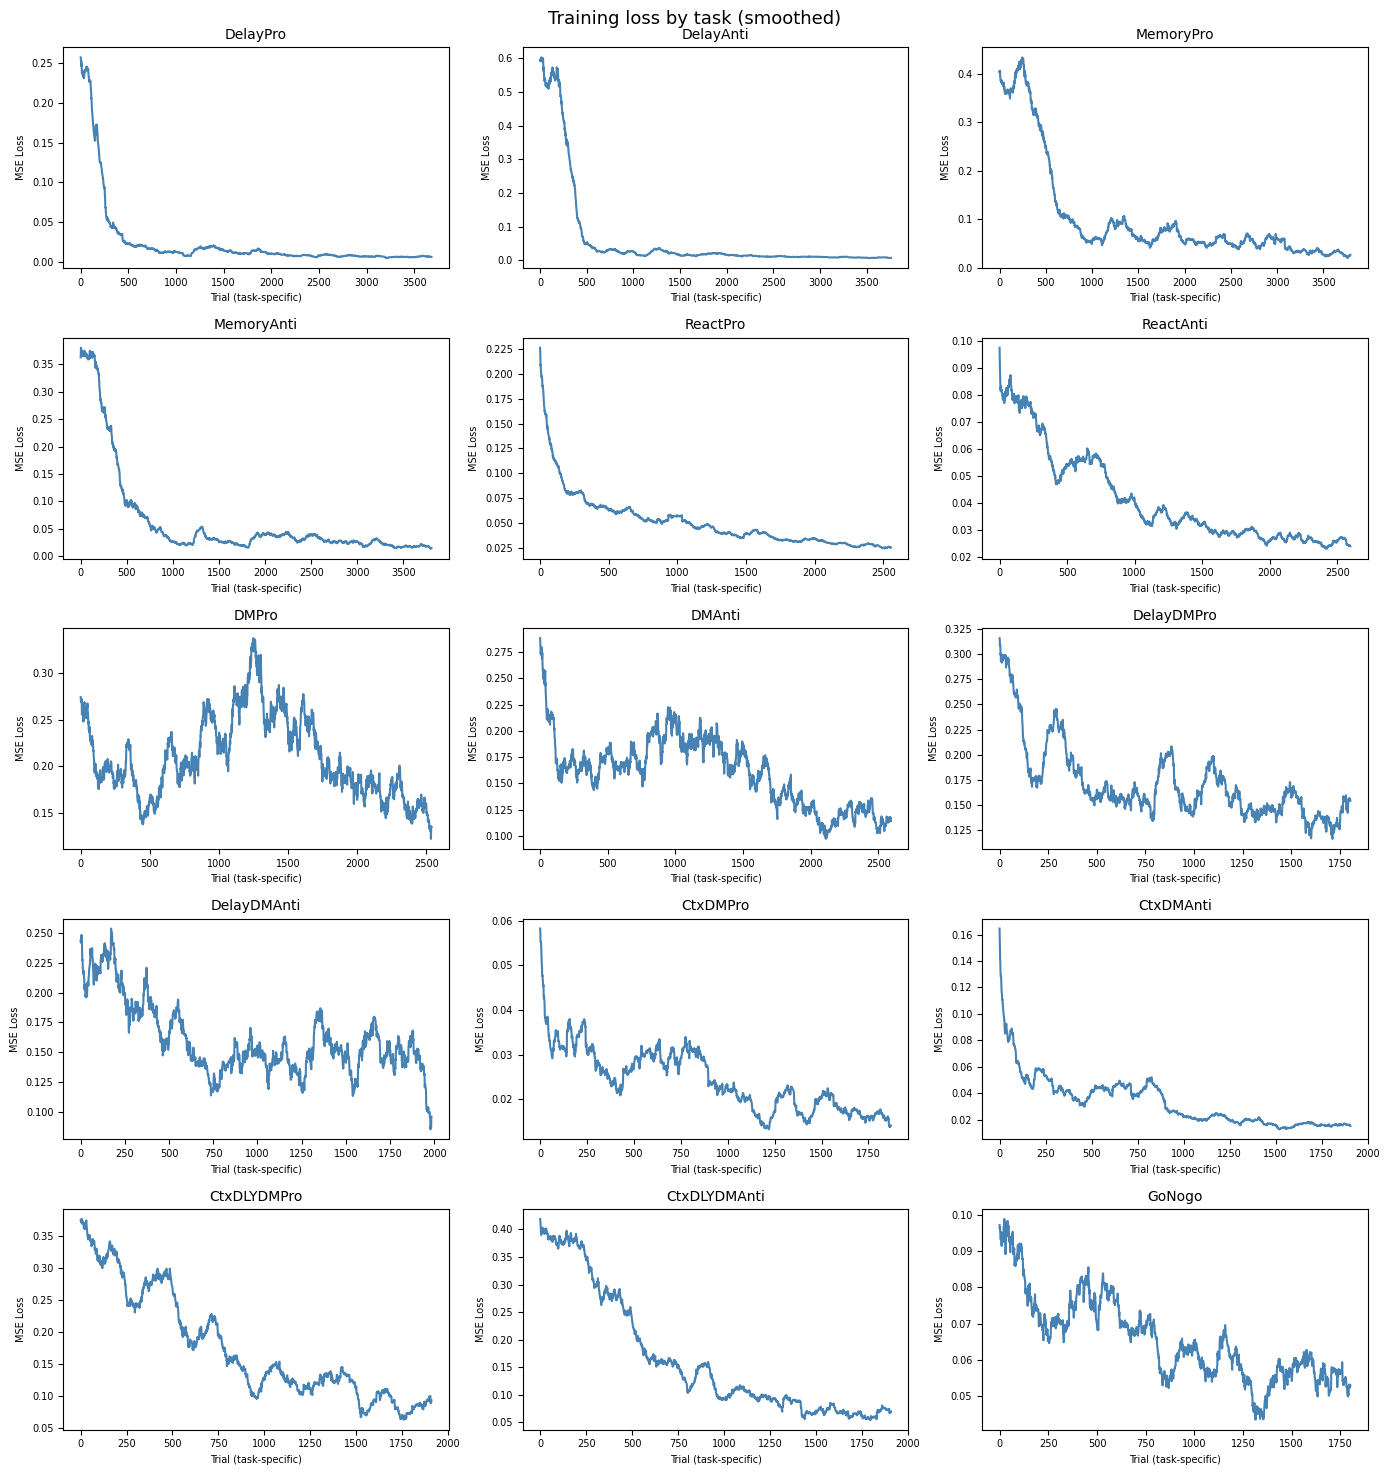

In [23]:
# ── Cell 6: Training Loss Curves ─────────────────────────────────
def smooth(x, w=100):
    return np.convolve(x, np.ones(w)/w, mode='valid') if len(x) >= w else np.array(x)

n_cols = 3
n_rows = (NUM_TASKS + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes = axes.flatten()

for i, task_name in enumerate(TASK_NAMES):
    ax  = axes[i]
    raw = losses[task_name]
    if raw:
        ax.plot(smooth(raw), color='steelblue')
    ax.set_title(task_name, fontsize=10)
    ax.set_xlabel('Trial (task-specific)', fontsize=7)
    ax.set_ylabel('MSE Loss', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Training loss by task (smoothed)', fontsize=13)
plt.tight_layout()
plt.show()

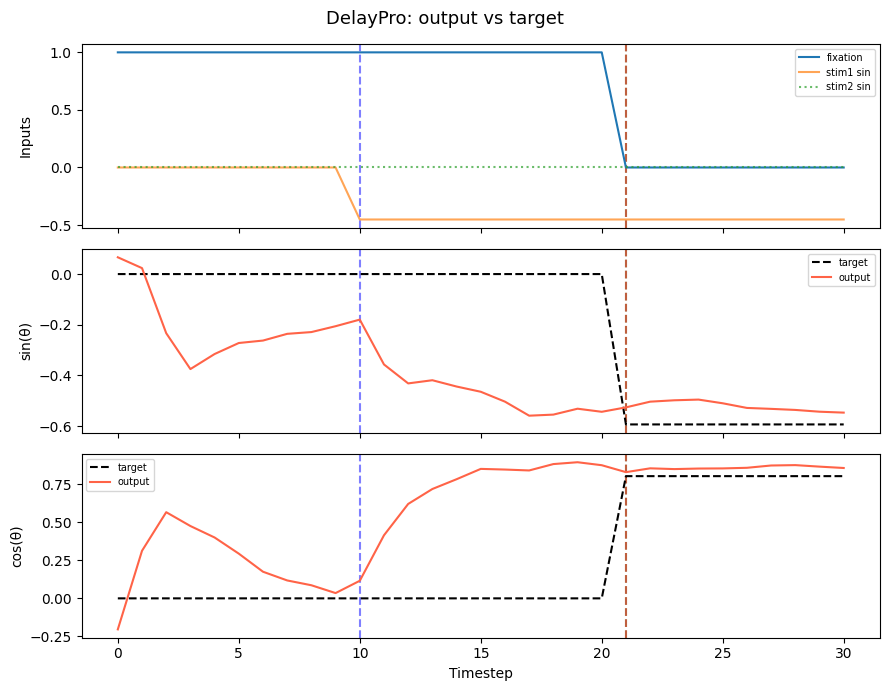

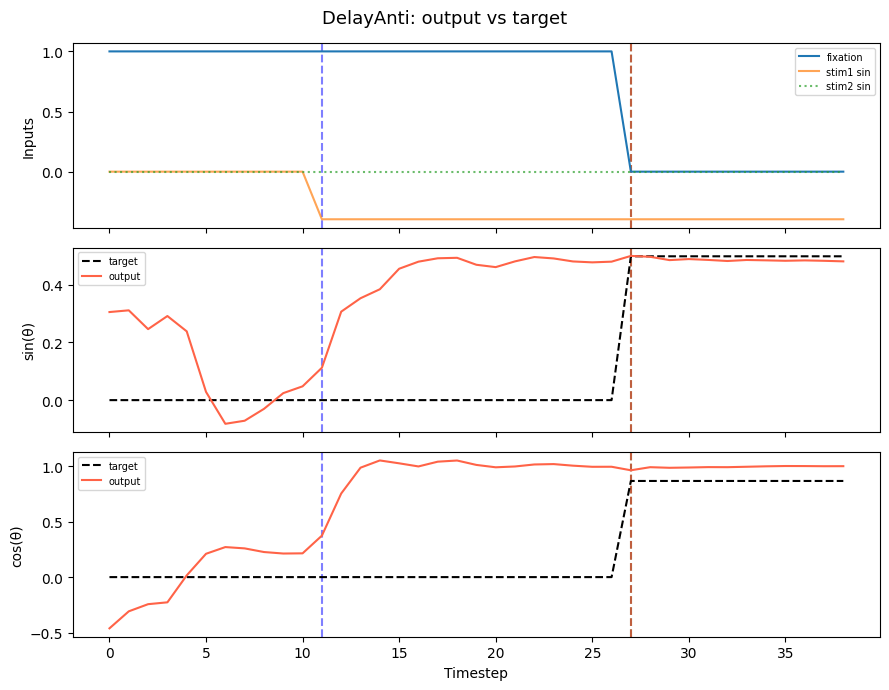

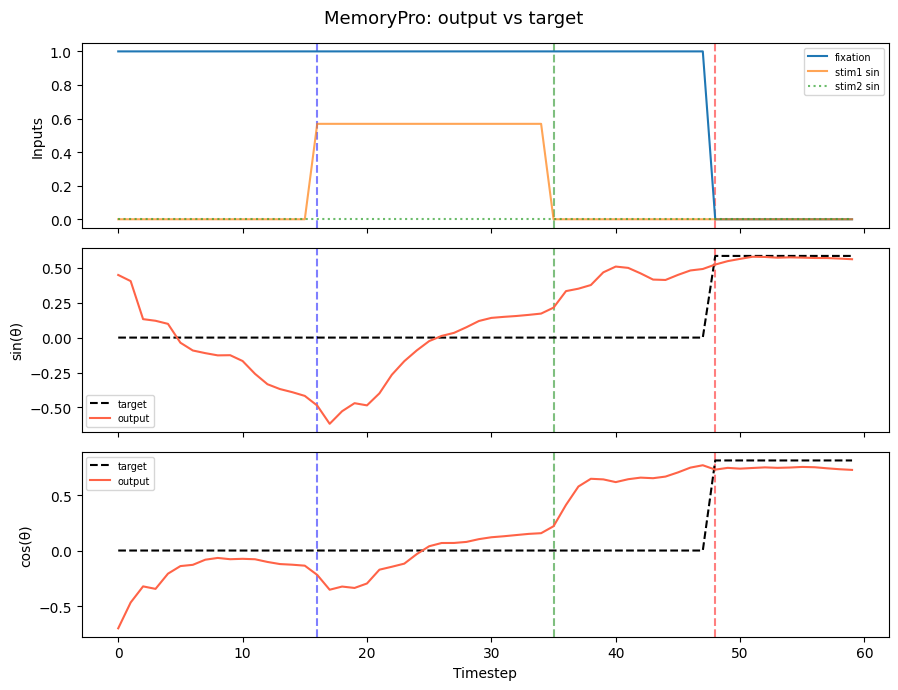

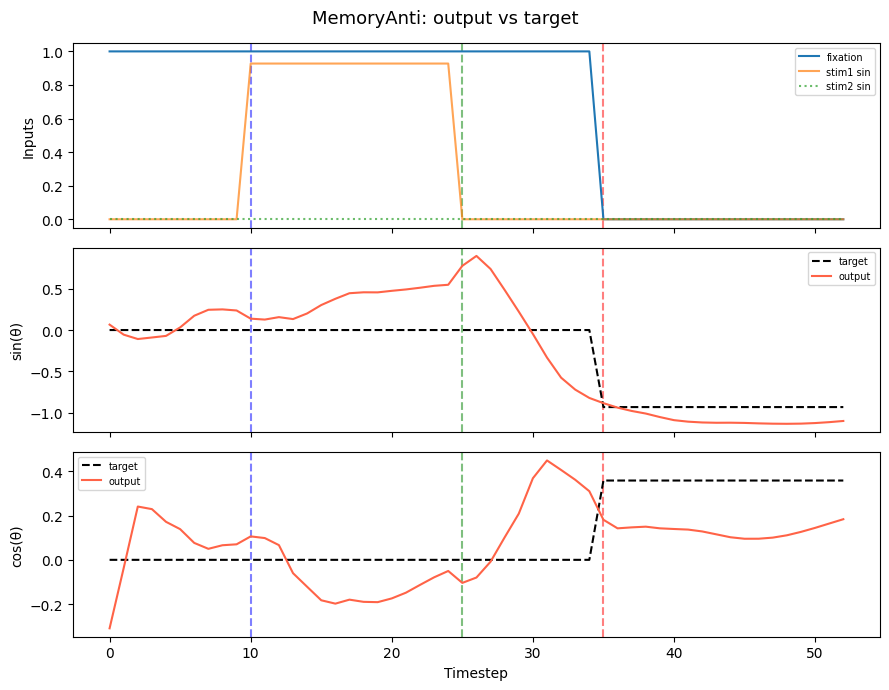

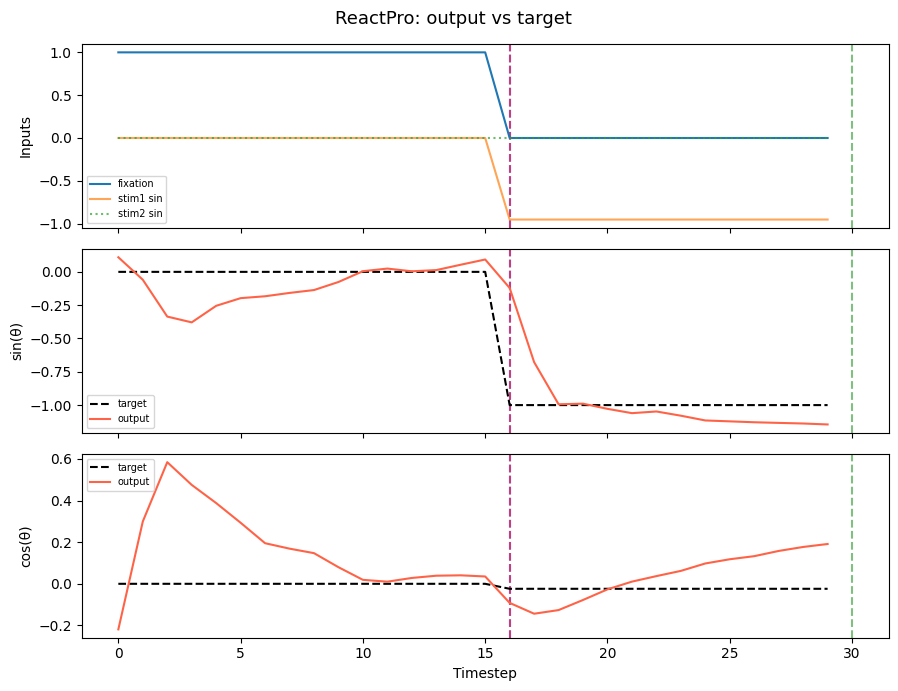

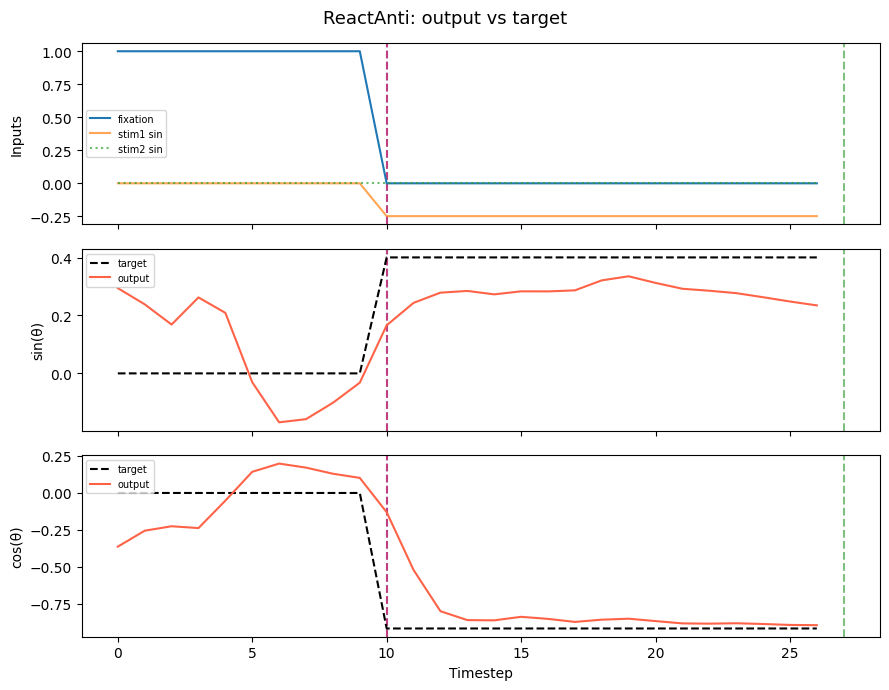

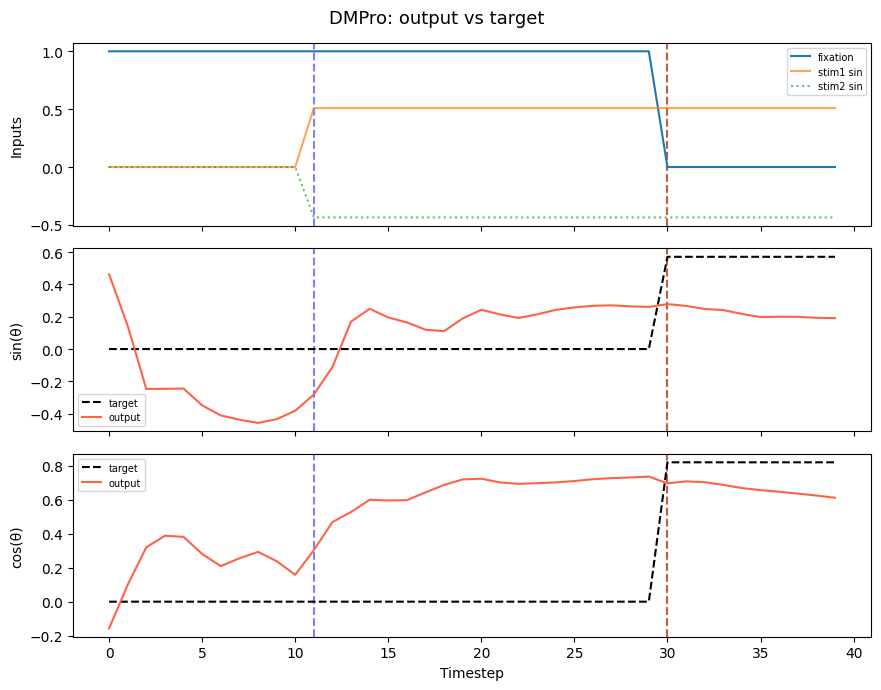

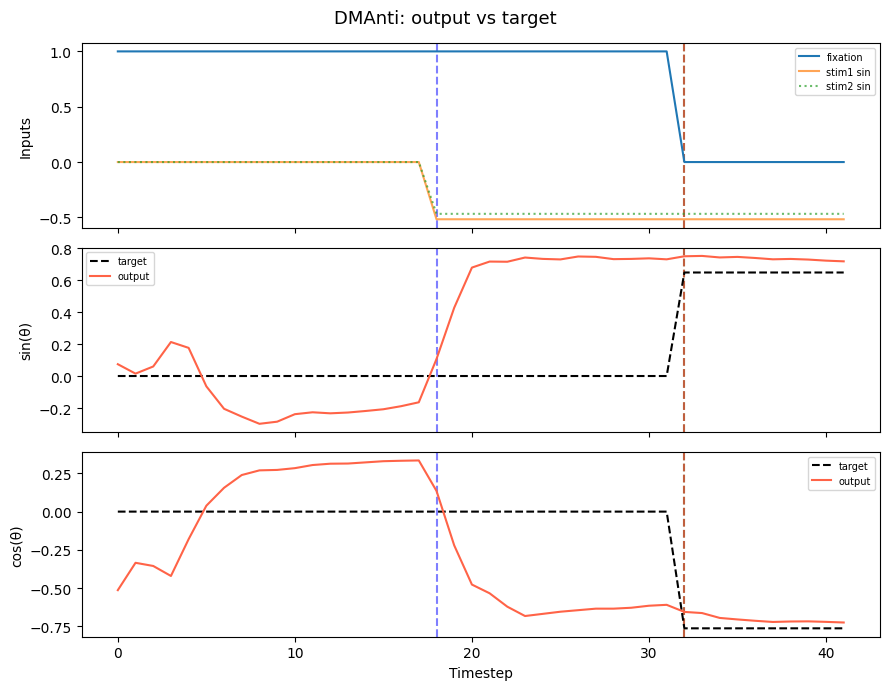

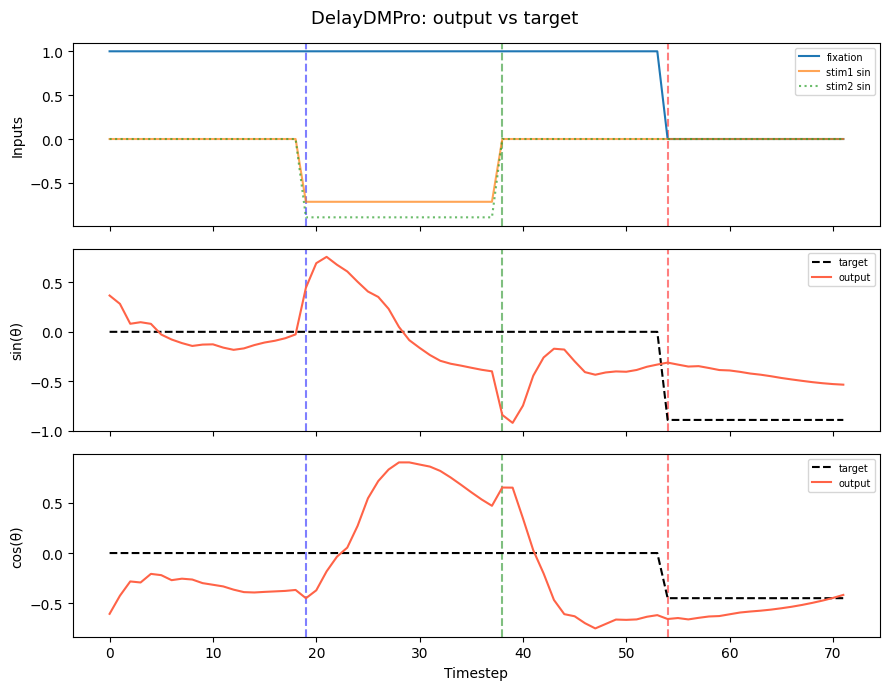

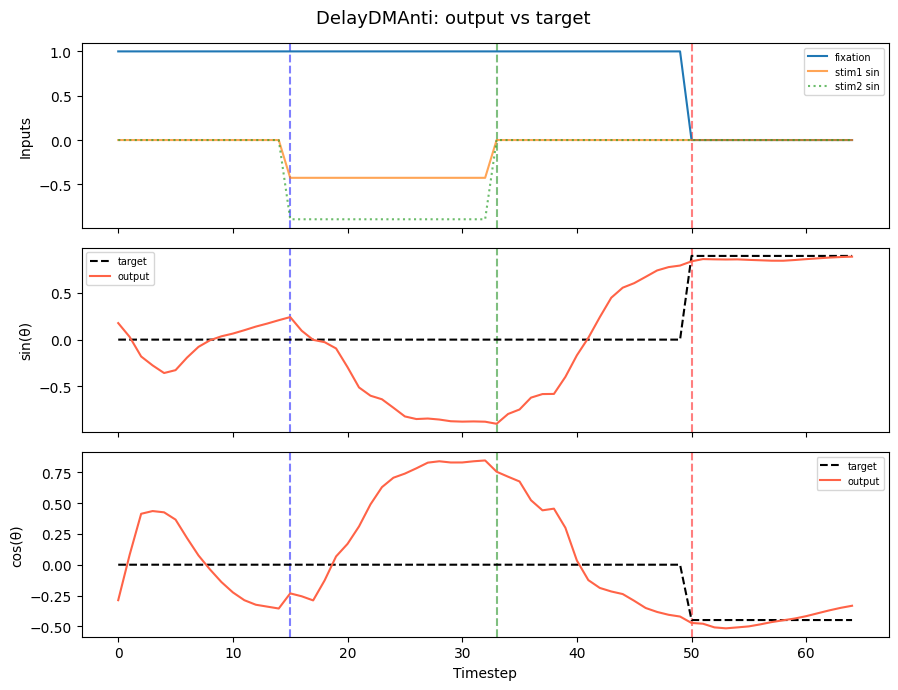

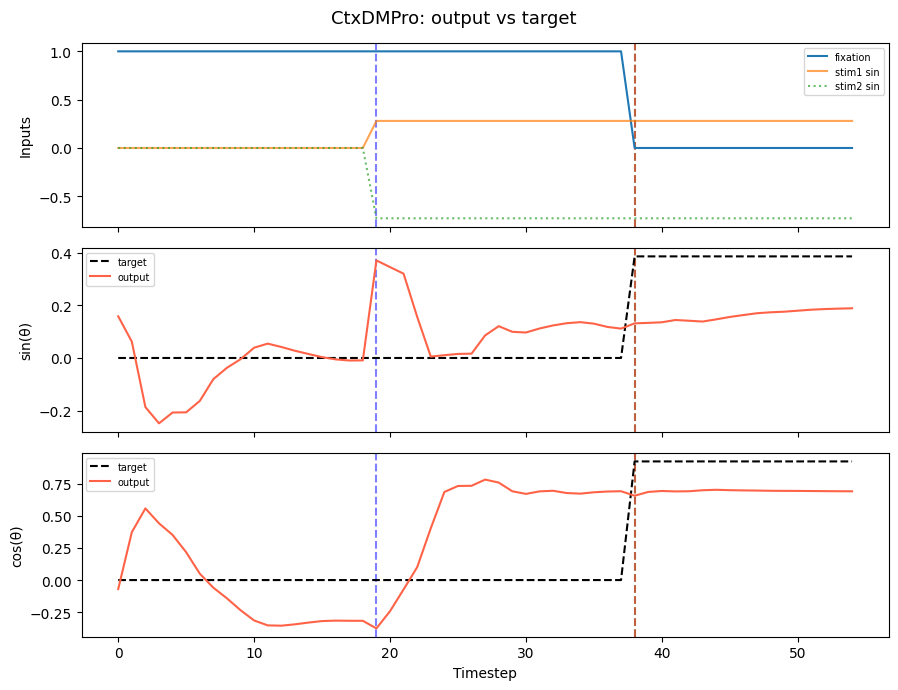

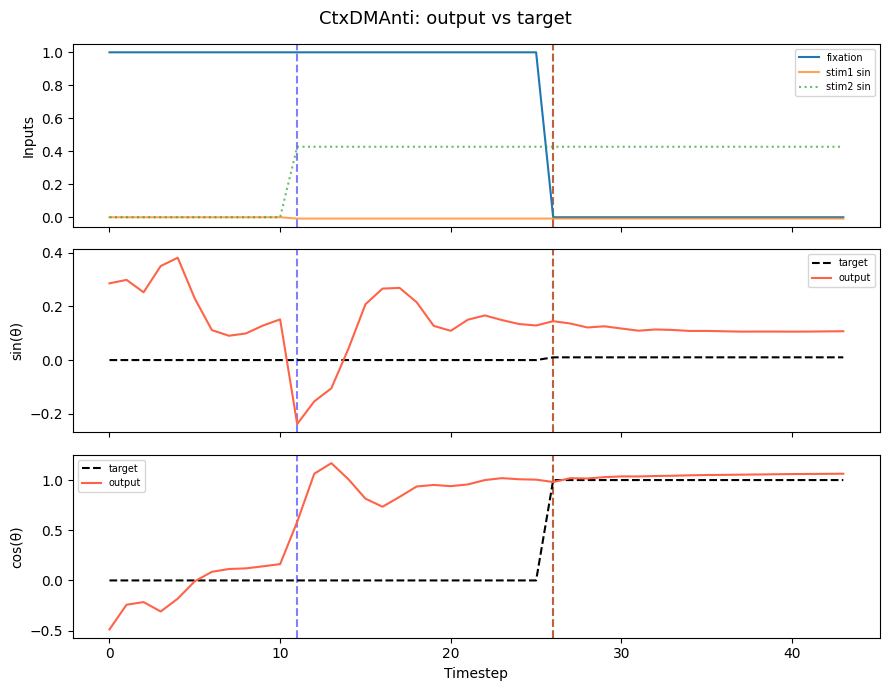

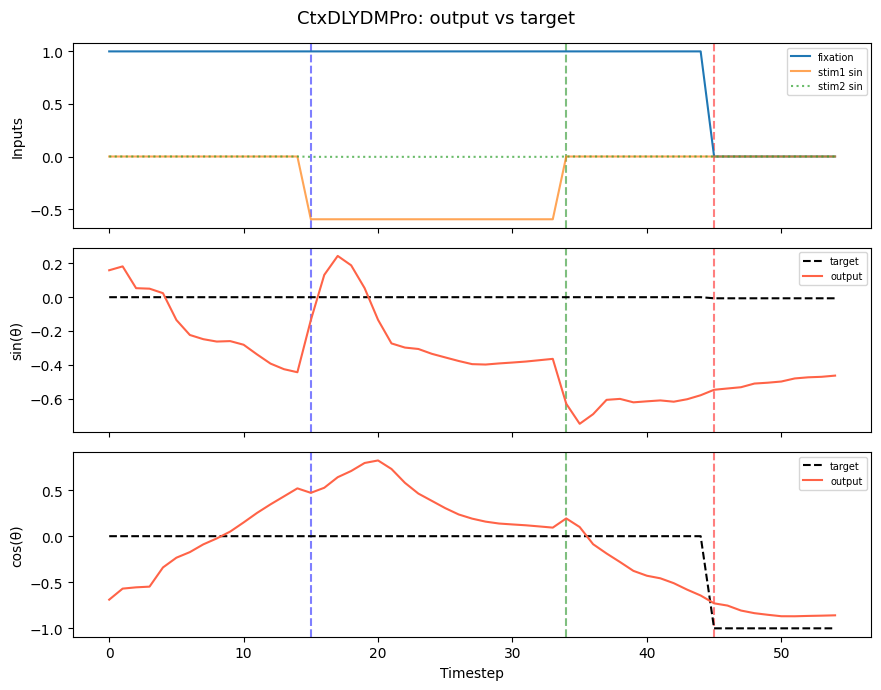

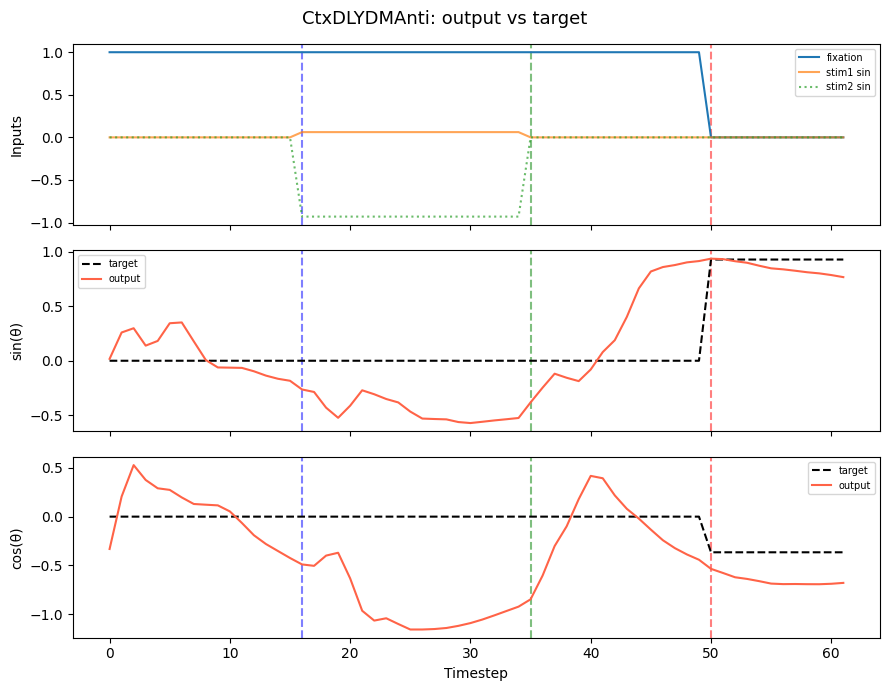

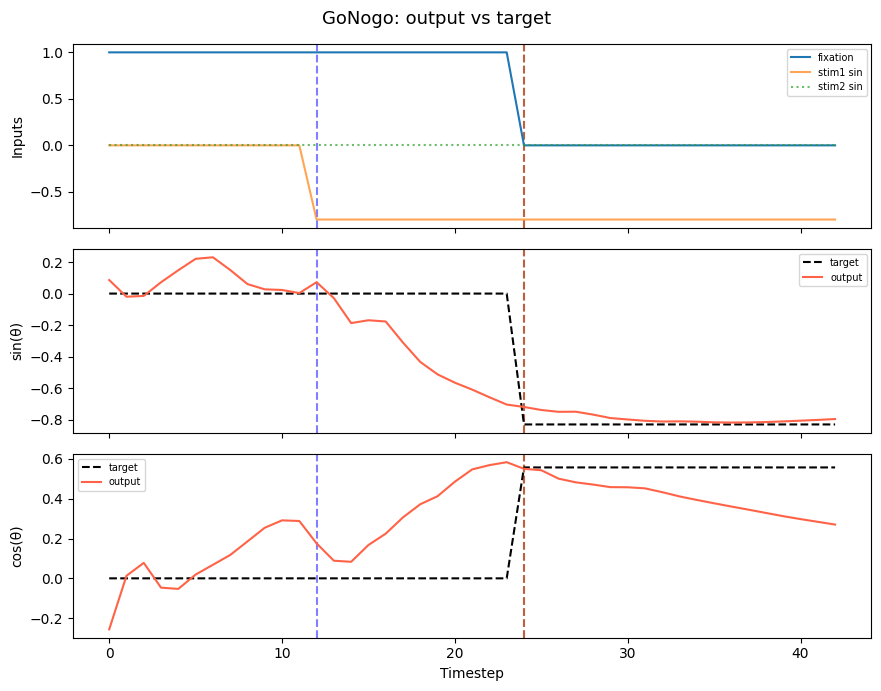

In [24]:
# ── Cell 7: Plot Any Trial ───────────────────────────────────────
# Vertical lines: blue=stim on, green=stim off/memory, red=go cue

def plot_trial(model, task_name, noise=0.0):
    model.eval()
    with torch.no_grad():
        inputs, targets, response_start, stim_start, stim_end = generate_trial(task_name, noise=noise)
        outputs = model(inputs.to(device)).cpu()

    T = inputs.shape[0]
    t = np.arange(T)

    fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
    for ax in axes:
        ax.axvline(stim_start,     color='b', linestyle='--', alpha=0.5)
        ax.axvline(stim_end,       color='g', linestyle='--', alpha=0.5)
        ax.axvline(response_start, color='r', linestyle='--', alpha=0.5)

    axes[0].plot(t, inputs[:, 0], label='fixation')
    axes[0].plot(t, inputs[:, 1], label='stim1 sin', alpha=0.7)
    axes[0].plot(t, inputs[:, 3], label='stim2 sin', alpha=0.7, linestyle=':')
    axes[0].set_ylabel('Inputs');  axes[0].legend(fontsize=7)

    axes[1].plot(t, targets[:, 1], 'k--', label='target')
    axes[1].plot(t, outputs[:, 1], color='tomato', label='output')
    axes[1].set_ylabel('sin(θ)');  axes[1].legend(fontsize=7)

    axes[2].plot(t, targets[:, 2], 'k--', label='target')
    axes[2].plot(t, outputs[:, 2], color='tomato', label='output')
    axes[2].set_ylabel('cos(θ)');  axes[2].set_xlabel('Timestep')
    axes[2].legend(fontsize=7)

    plt.suptitle(f'{task_name}: output vs target', fontsize=13)
    plt.tight_layout()
    plt.show()

for task in TASK_NAMES:
    plot_trial(model, task)

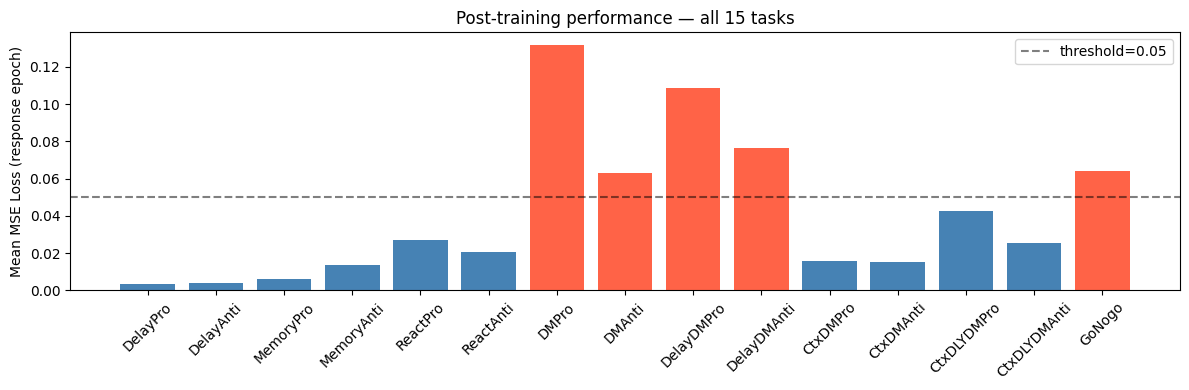


Task performance summary:
  DMPro                 loss=0.1320  NEEDS WORK
  DelayDMPro            loss=0.1088  NEEDS WORK
  DelayDMAnti           loss=0.0764  NEEDS WORK
  GoNogo                loss=0.0643  NEEDS WORK
  DMAnti                loss=0.0628  NEEDS WORK
  CtxDLYDMPro           loss=0.0427  OK
  ReactPro              loss=0.0270  OK
  CtxDLYDMAnti          loss=0.0256  OK
  ReactAnti             loss=0.0207  OK
  CtxDMPro              loss=0.0156  OK
  CtxDMAnti             loss=0.0151  OK
  MemoryAnti            loss=0.0136  OK
  MemoryPro             loss=0.0063  OK
  DelayAnti             loss=0.0039  OK
  DelayPro              loss=0.0033  OK


In [25]:
# ── Cell 8: Performance Summary ──────────────────────────────────
model.eval()
n_eval     = 50
eval_losses = {}

with torch.no_grad():
    for task_name in TASK_NAMES:
        task_losses = []
        for _ in range(n_eval):
            inputs, targets, response_start, _, _ = generate_trial(task_name, noise=0.01)
            outputs = model(inputs.to(device))
            loss    = loss_fn(outputs[response_start:], targets[response_start:].to(device))
            task_losses.append(loss.item())
        eval_losses[task_name] = np.mean(task_losses)

fig, ax = plt.subplots(figsize=(12, 4))
colors  = ['steelblue' if v < 0.05 else 'tomato' for v in eval_losses.values()]
ax.bar(eval_losses.keys(), eval_losses.values(), color=colors)
ax.axhline(0.05, color='k', linestyle='--', alpha=0.5, label='threshold=0.05')
ax.set_ylabel('Mean MSE Loss (response epoch)')
ax.set_title('Post-training performance — all 15 tasks')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print('\nTask performance summary:')
for name, val in sorted(eval_losses.items(), key=lambda x: -x[1]):
    status = 'OK' if val < 0.05 else 'NEEDS WORK'
    print(f'  {name:20s}  loss={val:.4f}  {status}')

PCA variance explained: PC1=0.33, PC2=0.22


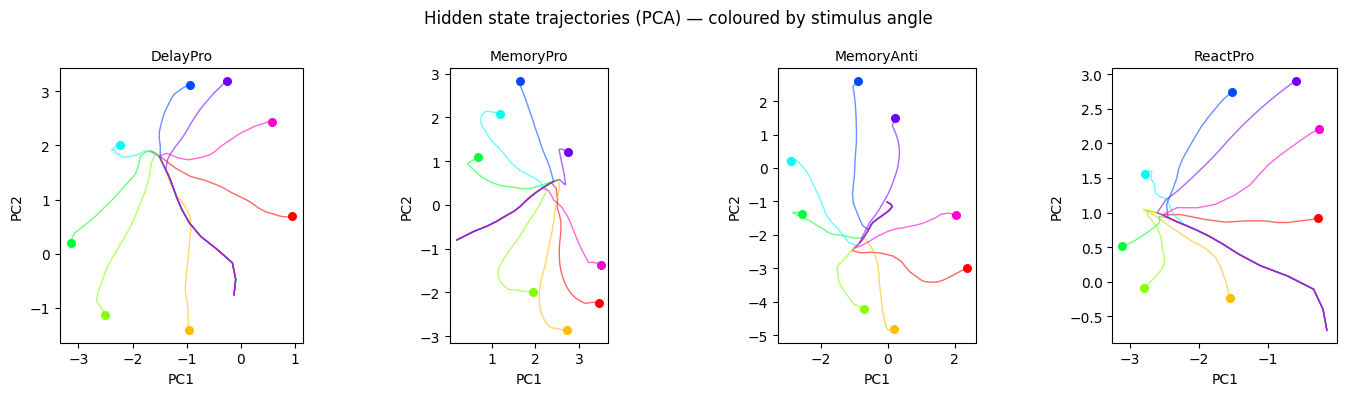

In [26]:
# ── Cell 9: Hidden State Trajectories (PCA) ──────────────────────
# Projects 256-dim hidden state down to 2D to visualise network dynamics.
# Each coloured line = one trial at a different stimulus angle.
# Tasks sharing computational structure should show similar trajectory shapes.

model.eval()
n_angles      = 8
angles        = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
tasks_to_plot = ['DelayPro', 'MemoryPro', 'MemoryAnti', 'ReactPro']

# Collect hidden states across tasks to fit PCA
all_hidden = []
with torch.no_grad():
    for task_name in tasks_to_plot:
        for _ in range(20):
            inputs, _, _, _, _ = generate_trial(task_name, noise=0.0)
            _, hidden = model(inputs.to(device), return_hidden=True)
            all_hidden.append(hidden.cpu().numpy())

all_hidden = np.concatenate(all_hidden, axis=0)
pca        = PCA(n_components=2)
pca.fit(all_hidden)
print(f'PCA variance explained: PC1={pca.explained_variance_ratio_[0]:.2f}, PC2={pca.explained_variance_ratio_[1]:.2f}')

fig, axes = plt.subplots(1, len(tasks_to_plot), figsize=(14, 4))
colors    = plt.cm.hsv(np.linspace(0, 1, n_angles, endpoint=False))

with torch.no_grad():
    for ax, task_name in zip(axes, tasks_to_plot):
        for angle, color in zip(angles, colors):
            inputs, _, response_start, stim_start, _ = generate_trial(task_name, noise=0.0)
            # override stimulus with fixed angle for clean visualisation
            inputs[stim_start:, 1] = float(np.sin(angle))
            inputs[stim_start:, 2] = float(np.cos(angle))
            _, hidden = model(inputs.to(device), return_hidden=True)
            proj = pca.transform(hidden.cpu().numpy())
            ax.plot(proj[:, 0], proj[:, 1], color=color, alpha=0.6, linewidth=1)
            ax.scatter(proj[-1, 0], proj[-1, 1], color=color, s=30, zorder=5)
        ax.set_title(task_name, fontsize=10)
        ax.set_xlabel('PC1');  ax.set_ylabel('PC2')
        ax.set_aspect('equal')

plt.suptitle('Hidden state trajectories (PCA) — coloured by stimulus angle', fontsize=12)
plt.tight_layout()
plt.show()

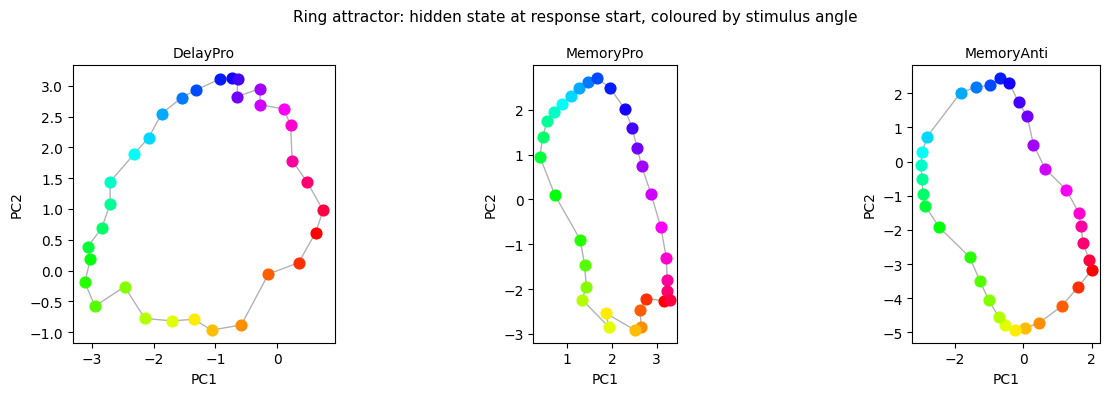

In [27]:
# ── Cell 10: Ring Attractor ──────────────────────────────────────
# At the end of the memory period, hidden states should form a ring —
# one point per stimulus angle, arranged in a circle.
# This is the dynamical motif Driscoll 2024 identifies for memory tasks.

model.eval()
n_angles       = 32
angles         = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
tasks_to_check = ['DelayPro', 'MemoryPro', 'MemoryAnti']

fig, axes = plt.subplots(1, len(tasks_to_check), figsize=(13, 4))
colors    = plt.cm.hsv(np.linspace(0, 1, n_angles, endpoint=False))

with torch.no_grad():
    for ax, task_name in zip(axes, tasks_to_check):
        endpoints = []
        for angle in angles:
            inputs, _, response_start, stim_start, _ = generate_trial(task_name, noise=0.0)
            inputs[stim_start:, 1] = float(np.sin(angle))
            inputs[stim_start:, 2] = float(np.cos(angle))
            _, hidden = model(inputs.to(device), return_hidden=True)
            # hidden state just before go cue = end of memory period
            endpoints.append(hidden.cpu().numpy()[response_start - 1])

        endpoints = np.array(endpoints)
        proj      = pca.transform(endpoints)

        for p, c in zip(proj, colors):
            ax.scatter(p[0], p[1], color=c, s=60, zorder=5)
        ring = np.vstack([proj, proj[0]])
        ax.plot(ring[:, 0], ring[:, 1], 'k-', alpha=0.3, linewidth=1)

        ax.set_title(f'{task_name}', fontsize=10)
        ax.set_xlabel('PC1');  ax.set_ylabel('PC2')
        ax.set_aspect('equal')

plt.suptitle('Ring attractor: hidden state at response start, coloured by stimulus angle', fontsize=11)
plt.tight_layout()
plt.show()

In [28]:
# ── Cell 11: Reload Saved Weights ───────────────────────────────

from google.colab import drive
drive.mount('/content/drive')
model = RNN(hidden_size=256).to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/multitask_rnn.pt', map_location=device))
model.eval()
print('Weights loaded successfully.')

MessageError: Error: credential propagation was unsuccessful

In [29]:
# ── Cell 12: Task Variance Analysis ─────────────────────────────
# For each hidden unit, compute how much its activity varies across tasks.
# High task variance = unit is selective for specific tasks.
# Low task variance  = unit is active similarly across all tasks.
#
# Following Yang et al. 2019: task variance is the variance of
# per-task mean activities across tasks.

model.eval()
n_trials_per_task = 50  # trials per task to estimate mean activity

# unit_task_means[task_idx, unit_idx] = mean activity of that unit
# during the response epoch, averaged over n_trials_per_task trials
unit_task_means = np.zeros((NUM_TASKS, model.hidden_size))

with torch.no_grad():
    for t_idx, task_name in enumerate(TASK_NAMES):
        task_hidden = []
        for _ in range(n_trials_per_task):
            inputs, _, response_start, _, _ = generate_trial(task_name, noise=0.01)
            _, hidden = model(inputs.to(device), return_hidden=True)
            # take mean hidden state over the response epoch
            response_hidden = hidden[response_start:].cpu().numpy()
            task_hidden.append(response_hidden.mean(axis=0))  # [hidden_size]
        unit_task_means[t_idx] = np.mean(task_hidden, axis=0)

# Task variance: for each unit, variance of its mean activity across tasks
task_variance = unit_task_means.var(axis=0)  # [hidden_size]

print(f'Task variance — min: {task_variance.min():.4f}, '
      f'max: {task_variance.max():.4f}, '
      f'mean: {task_variance.mean():.4f}')

# Rank units by task variance
ranked_units = np.argsort(task_variance)[::-1]  # highest first
print(f'\nTop 10 most task-selective units: {ranked_units[:10]}')
print(f'Bottom 10 least task-selective units: {ranked_units[-10:]}')

Task variance — min: 0.0001, max: 0.5096, mean: 0.0235

Top 10 most task-selective units: [129 201  73  19  38 251  40 135  98 250]
Bottom 10 least task-selective units: [ 48   2 240 222  95 214 234 177  80  13]


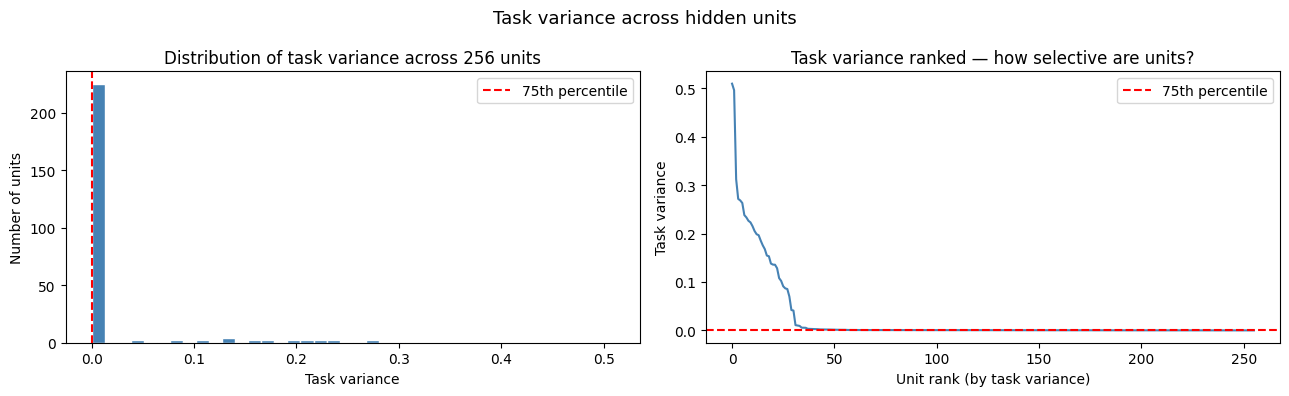

In [30]:
# ── Cell 13: Task Variance Distribution ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram of task variance across all units
axes[0].hist(task_variance, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Task variance')
axes[0].set_ylabel('Number of units')
axes[0].set_title('Distribution of task variance across 256 units')
axes[0].axvline(np.percentile(task_variance, 75), color='r',
                linestyle='--', label='75th percentile')
axes[0].legend()

# Right: task variance ranked (highest to lowest)
# This is the key plot — shows how many units are truly task-selective
axes[1].plot(np.sort(task_variance)[::-1], color='steelblue')
axes[1].set_xlabel('Unit rank (by task variance)')
axes[1].set_ylabel('Task variance')
axes[1].set_title('Task variance ranked — how selective are units?')
axes[1].axhline(np.percentile(task_variance, 75), color='r',
                linestyle='--', label='75th percentile')
axes[1].legend()

plt.suptitle('Task variance across hidden units', fontsize=13)
plt.tight_layout()
plt.show()

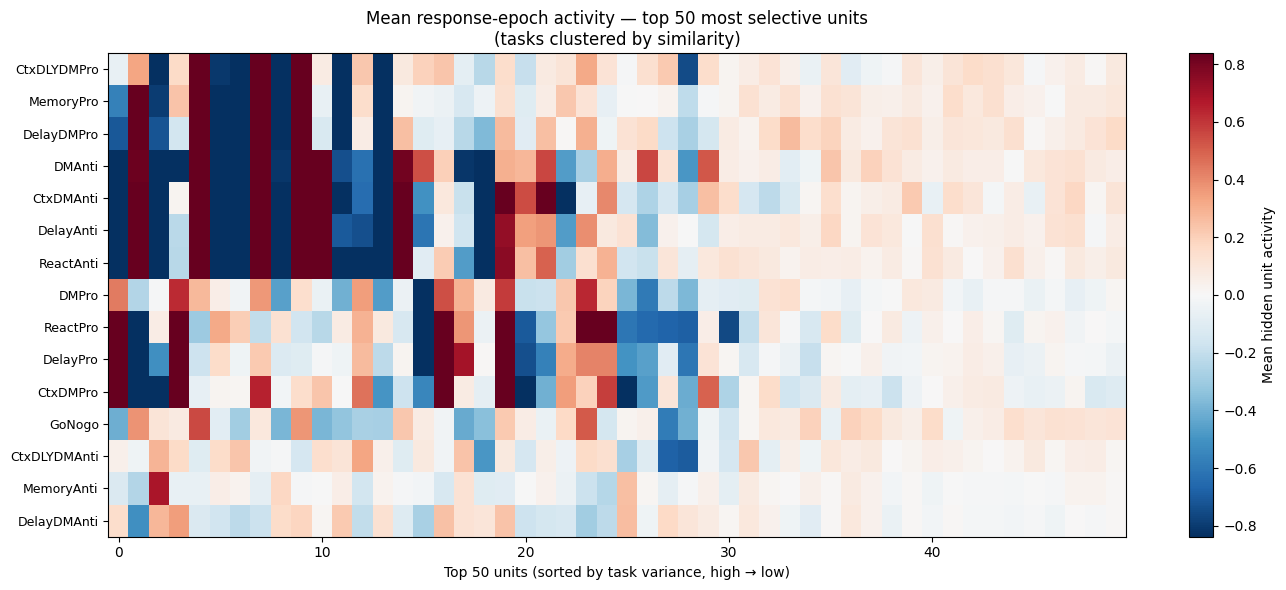

In [33]:
# ── Cell 14: Unit-Task Activity Heatmap (improved) ───────────────
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Only show top 50 most selective units — low variance units add noise
n_show    = 50
top_units = ranked_units[:n_show]
top_means = unit_task_means[:, top_units]  # [NUM_TASKS, n_show]

# Normalize each task's profile before clustering
# (captures pattern shape, not magnitude)
top_means_normalized = (top_means - top_means.mean(axis=1, keepdims=True))

# Cluster task rows by similarity so related tasks appear together
row_linkage = linkage(pdist(top_means_normalized), method='ward')
row_order   = dendrogram(row_linkage, no_plot=True)['leaves']

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(top_means_normalized[row_order], aspect='auto', cmap='RdBu_r',
               vmin=-top_means_normalized.std()*2,
               vmax=top_means_normalized.std()*2)

ax.set_yticks(range(NUM_TASKS))
ax.set_yticklabels([TASK_NAMES[i] for i in row_order], fontsize=9)
ax.set_xlabel('Top 50 units (sorted by task variance, high → low)')
ax.set_title('Mean response-epoch activity — top 50 most selective units\n'
             '(tasks clustered by similarity)')
plt.colorbar(im, ax=ax, label='Mean hidden unit activity')
plt.tight_layout()
plt.show()

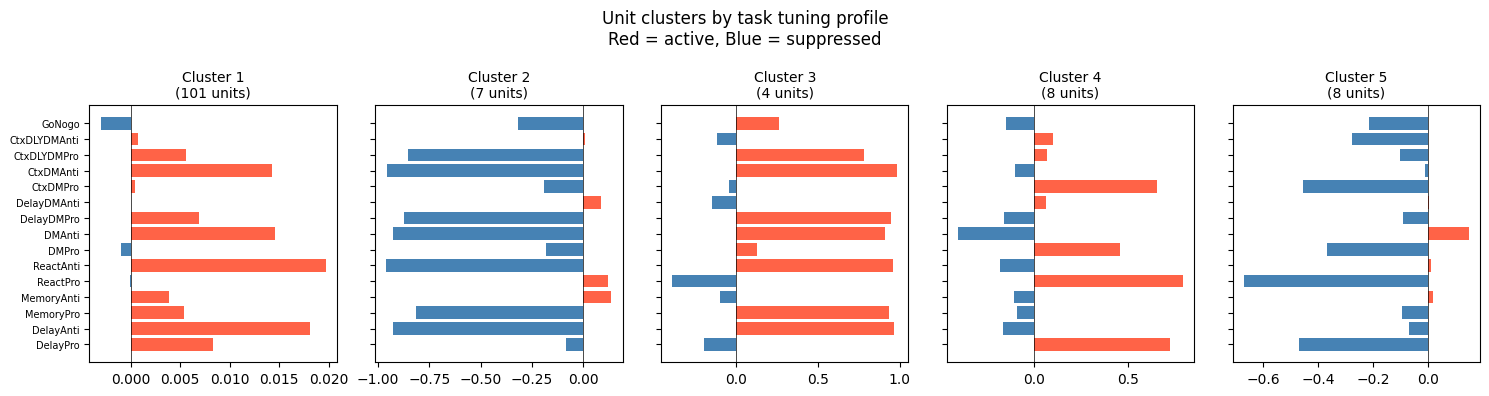

In [32]:
# ── Cell 15: Cluster Units by Task Tuning ───────────────────────
# Group units that have similar patterns of task selectivity.
# Units that are both active for MemoryPro AND MemoryAnti but not ReactPro
# would cluster together — these are "memory units."

from sklearn.cluster import KMeans

# Only cluster the top 50% most task-selective units
# (bottom half have near-zero variance and aren't interesting)
n_selective = model.hidden_size // 2
selective_units = ranked_units[:n_selective]
selective_means = unit_task_means[:, selective_units].T  # [n_selective, NUM_TASKS]

# Normalize each unit's profile to unit variance before clustering
# (so clustering captures pattern shape, not magnitude)
from sklearn.preprocessing import StandardScaler
scaler  = StandardScaler()
scaled  = scaler.fit_transform(selective_means)

# K-means clustering — try 5 clusters (adjust based on what you see)
n_clusters = 5
kmeans     = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels     = kmeans.fit_predict(scaled)

# Plot mean tuning profile for each cluster
fig, axes = plt.subplots(1, n_clusters, figsize=(15, 4), sharey=True)

for c in range(n_clusters):
    cluster_units = selective_means[labels == c]  # units in this cluster
    mean_profile  = cluster_units.mean(axis=0)    # mean activity per task

    axes[c].barh(TASK_NAMES, mean_profile,
                 color=['tomato' if v > 0 else 'steelblue' for v in mean_profile])
    axes[c].axvline(0, color='k', linewidth=0.5)
    axes[c].set_title(f'Cluster {c+1}\n({(labels==c).sum()} units)', fontsize=10)
    axes[c].tick_params(axis='y', labelsize=7)

plt.suptitle('Unit clusters by task tuning profile\n'
             'Red = active, Blue = suppressed', fontsize=12)
plt.tight_layout()
plt.show()